<a href="https://colab.research.google.com/github/Ewha-Euron/10th-ML/blob/week_5/Week4_%EB%B3%B5%EC%8A%B5%EA%B3%BC%EC%A0%9C_%EB%AC%B8%EC%A0%9C%EC%A7%80_4%ED%8C%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week4_복습과제_문제지_4팀

# 1. GBM

* GBM & XGBoost 실습에 사용할 데이터의 로드 및 전처리를 위해 먼저 아래의 셀을 실행해야 합니다.
* 피마 인디언 당뇨병 데이터셋을 사용합니다.

In [25]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

In [26]:
# 데이터 로드 (URL을 통해 직접 다운로드)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
diabetes_df = pd.read_csv(url, names=column_names)

# 피처와 레이블 분리
X_features = diabetes_df.iloc[:, :-1]
y_label = diabetes_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용, 20%는 테스트용 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156, stratify=y_label
)

# 학습 데이터를 다시 9:1로 나누어 검증 데이터 생성 (조기 중단용)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156, stratify=y_train
)

1) eta(learning_rate) 값을 ( 낮춘다 )

2) max_depth 값을 ( 낮춘다 )

3) min_child_weight 값을 ( 높인다 )

### 1-1. GBM 모델 학습 및 시간 측정

* GradientBoostingClassifier를 사용하여 학습과 예측을 수행하세요.
* 빈칸을 채워 정확도와 수행 시간을 출력하세요.

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초 ".format(time.time() - start_time))

GBM 정확도: 0.7208
GBM 수행 시간: 0.3 초 


### 1-2. GBM의 특성에 대한 OX 퀴즈

* 괄호 안에 O/X를 기입하고 근거를 작성하세요.

1) ( X ) GBM은 순차적으로 오류를 보정해 나가는 방식이므로 랜덤 포레스트보다 하이퍼 파라미터 튜닝이 덜 까다롭다.

* 근거: GBM은 순차적으로 예측 오류를 개선하기 때문에 작은 변화에도 민감하게 반응하여 하이퍼 파라미터 튜닝이 랜덤 포레스트보다 더 까다롭습니다.

2) ( O ) GBM은 멀티 CPU 코어 시스템에서도 병렬 처리를 지원하지 않아 대용량 데이터 학습에 시간이 오래 걸린다.

* 근거: 전통적인 GBM은 이전 트리의 예측 오차를 보정하며 다음 트리를 생성하는 순차적인 방식이므로 병렬 처리가 어렵습니다. XGBoost나 LightGBM은 이를 개선하여 병렬 처리를 지원합니다.

# 2. XGBoost

### 2-1. 파이썬 래퍼 XGBoost

* DMatrix를 생성하고, 제시된 하이퍼 파라미터로 학습을 수행하세요.
* 조건:
  * `max_depth=3`
  * `eta=0.05`
  * `objective='binary:logistic'`
  * `eval_metric='logloss'`
  * `num_rounds=400 `

In [28]:
import xgboost as xgb

# DMatrix 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

# 하이퍼 파라미터 설정
params = {
    'max_depth': 3,
    'eta': 0.05,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss'
}
num_rounds = 400

eval_list = [(dtr, 'train'), (dval, 'eval')]
xgb_model = xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=100, evals=eval_list)

[0]	train-logloss:0.63096	eval-logloss:0.63321
[1]	train-logloss:0.61729	eval-logloss:0.61562
[2]	train-logloss:0.60464	eval-logloss:0.60211
[3]	train-logloss:0.59320	eval-logloss:0.59067
[4]	train-logloss:0.58247	eval-logloss:0.57811
[5]	train-logloss:0.57272	eval-logloss:0.56626
[6]	train-logloss:0.56309	eval-logloss:0.55661
[7]	train-logloss:0.55456	eval-logloss:0.54793
[8]	train-logloss:0.54617	eval-logloss:0.54036
[9]	train-logloss:0.53827	eval-logloss:0.53328
[10]	train-logloss:0.53023	eval-logloss:0.52613
[11]	train-logloss:0.52392	eval-logloss:0.51890
[12]	train-logloss:0.51737	eval-logloss:0.51408
[13]	train-logloss:0.51133	eval-logloss:0.50812
[14]	train-logloss:0.50519	eval-logloss:0.50296
[15]	train-logloss:0.49985	eval-logloss:0.49799
[16]	train-logloss:0.49508	eval-logloss:0.49205
[17]	train-logloss:0.49031	eval-logloss:0.48889
[18]	train-logloss:0.48569	eval-logloss:0.48472
[19]	train-logloss:0.48136	eval-logloss:0.48129
[20]	train-logloss:0.47674	eval-logloss:0.47904
[2

### 2-2. 예측 확률의 이해 및 이진 분류 변환

* 파이썬 래퍼의 predict()는 objective가 'binary:logistic'일 경우 확률값을 반환합니다.
* 반면 사이킷런 래퍼(XGBClassifier)의 predict()는 내부적으로 이 가공 과정을 거쳐 바로 0 또는 1을 반환합니다.
* 파이썬 래퍼 XGBoost의 predict() 결과가 어떻게 출력되는지 확인하고, 이를 임계값(Threshold) 0.5를 기준으로 이진 분류 결과로 가공하세요.

In [29]:
pred_probs = xgb_model.predict(dtest)
print(np.round(pred_probs[:10], 3))

preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print(preds[:10])

[0.006 0.335 0.276 0.774 0.1   0.503 0.798 0.342 0.195 0.196]
[0, 0, 0, 1, 0, 1, 1, 0, 0, 0]


### 2-3. 사이킷런 래퍼 XGBoost

* XGBClassifier 클래스의 fit() 메서드 내 빈칸을 채우세요.

In [30]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric="logloss"
    )
evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(
    X_tr, y_tr,
    eval_set=evals,
    verbose=True
)

ws50_preds = xgb_wrapper.predict(X_test)
print('XGBoost 정확도:', accuracy_score(y_test, ws50_preds))

[0]	validation_0-logloss:0.63096	validation_1-logloss:0.63321
[1]	validation_0-logloss:0.61729	validation_1-logloss:0.61562
[2]	validation_0-logloss:0.60464	validation_1-logloss:0.60211
[3]	validation_0-logloss:0.59320	validation_1-logloss:0.59067
[4]	validation_0-logloss:0.58247	validation_1-logloss:0.57811
[5]	validation_0-logloss:0.57272	validation_1-logloss:0.56626
[6]	validation_0-logloss:0.56309	validation_1-logloss:0.55661
[7]	validation_0-logloss:0.55456	validation_1-logloss:0.54793
[8]	validation_0-logloss:0.54617	validation_1-logloss:0.54036
[9]	validation_0-logloss:0.53827	validation_1-logloss:0.53328
[10]	validation_0-logloss:0.53023	validation_1-logloss:0.52613
[11]	validation_0-logloss:0.52392	validation_1-logloss:0.51890
[12]	validation_0-logloss:0.51737	validation_1-logloss:0.51408
[13]	validation_0-logloss:0.51133	validation_1-logloss:0.50812
[14]	validation_0-logloss:0.50519	validation_1-logloss:0.50296
[15]	validation_0-logloss:0.49985	validation_1-logloss:0.49799
[1

* 실습을 진행하시며 느끼신 파이썬 래퍼 클래스와 비교되는 사이킷런 래퍼 클래스만의 특징이 무엇인가요?
* 답안: 사이킷런 래퍼 클래스(XGBClassifier)는 사이킷런의 `fit()`, `predict()` 등의 표준 API를 제공하여 사용하기 편리합니다. 또한 `early_stopping_rounds`, `eval_set`과 같은 파라미터를 `fit` 메서드에서 직접 전달할 수 있어 코드의 직관성이 높습니다. 반면 파이썬 래퍼는 `DMatrix` 변환이 필요하고 `xgb.train()` 함수를 직접 호출해야 하는 등 더 세부적인 제어를 요구합니다.

### 2-4. 시각화 및 해석

* plot_importance를 사용하여 피처 중요도를 시각화하세요.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

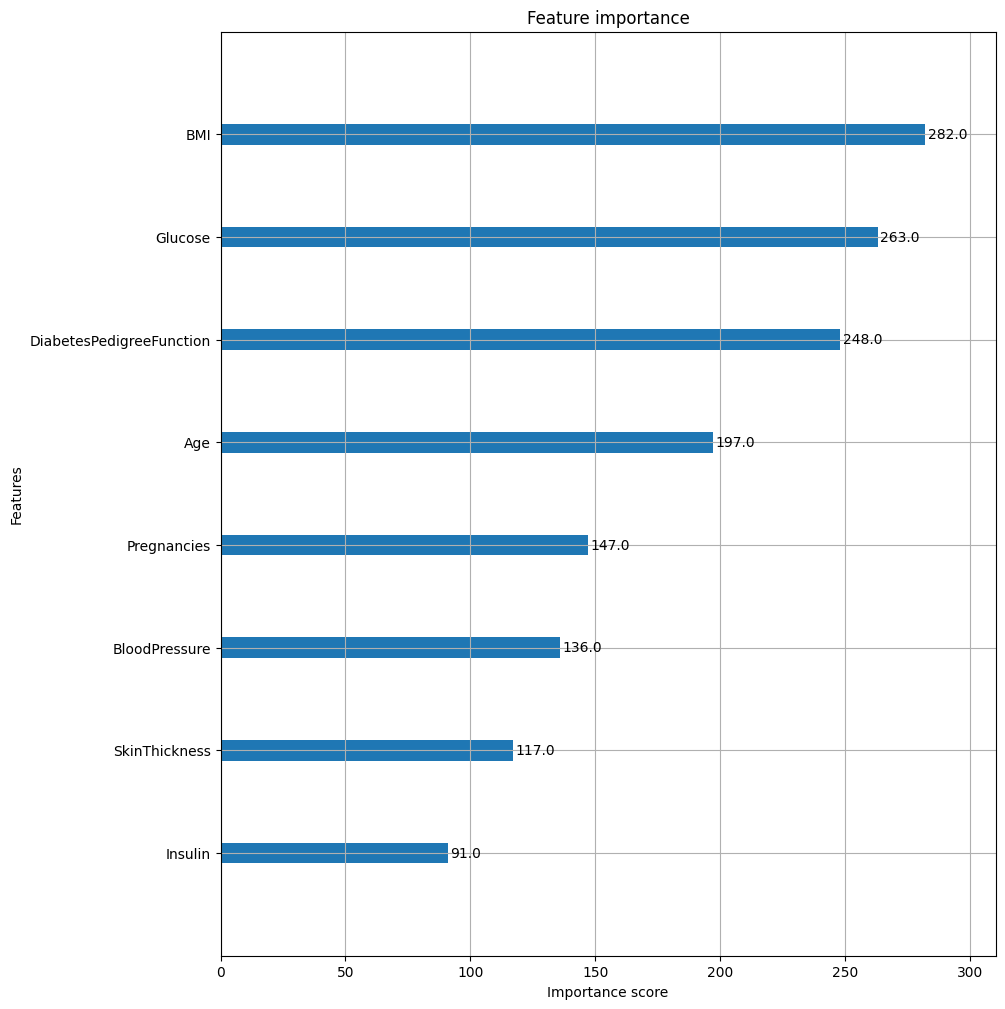

In [31]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_wrapper, ax=ax)

* 학습에 가장 영향을 많이 끼친 피처는 무엇인가요?

* 답안: (이 셀의 실행 결과에 따라 달라지지만, 일반적인 피마 인디언 당뇨병 데이터셋에서는 Glucose가 가장 중요한 피처 중 하나입니다. 코드 실행 후 plot_importance 결과를 보고 정확한 피처 이름을 기입해야 합니다.) Glucose

### 2-5. 과적합 방지를 위한 튜닝

* XGBoost 모델이 과적합(Overfitting) 되었을 때 조정해야 할 방향으로 알맞은 것을 고르세요.

1) eta(learning_rate) 값을 (높인다 / 낮춘다)

2) max_depth 값을 (높인다 / 낮춘다)

3) min_child_weight 값을 (높인다 / 낮춘다)



---



#3. LightGBM

먼저 아래 코드를 실행하여 데이터를 준비해주세요.

이번에는 load_breast_cancer와 유사한 와인 데이터셋을 사용합니다.

In [32]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, plot_importance
import matplotlib.pyplot as plt

# 데이터 로드 및 분리
wine = load_wine()
X_features = wine.data
y_label = wine.target

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# LightGBM의 조기 중단을 위해 검증 데이터 세트를 별도로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

##문제1. LightGBM 모델 생성과 하이퍼 파라미터

LightGBM 분류기인 LGBMClassifier을 생성하려고 합니다.

반복수행하려는 트리의 개수는 400개로 설정하고, 학습률은 0.05로 설정하는 코드를 완성하세요

In [33]:
from lightgbm import LGBMClassifier
# 빈칸을 채워 모델을 생성하세요.
lgbm_wrapper = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=156
)

##문제 2. 조기 중단(Early Stopping) 설정과 학습

학습 시 검증 데이터 세트를 지정하고, 100회 반복 동안 성능 지표가 향상되지 않으면 학습을 종료하도록 설정하려 합니다.

LightGBM 최신버전에 맞게 빈칸에 필요한 모듈을 입력하세요.

In [34]:
from lightgbm import early_stopping, log_evaluation

# 검증 데이터 세트 설정
evals = [(X_tr, y_tr), (X_val, y_val)]

# 최신 방식의 콜백 리스트 생성
# 100회 동안 개선 없으면 중단, 10회마다 로그 출력
my_callbacks = [
    early_stopping(stopping_rounds=100),
    log_evaluation(period=10)
]

# 모델 학습
lgbm_wrapper.fit(
    X_tr, y_tr,
    eval_metric='logloss',
    eval_set=evals,
    callbacks=(my_callbacks) # 콜백 리스트 전달
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 455
[LightGBM] [Info] Number of data points in the train set: 127, number of used features: 13
[LightGBM] [Info] Start training from score -1.082987
[LightGBM] [Info] Start training from score -0.952367
[LightGBM] [Info] Start training from score -1.288839
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

LGBMClassifier(learning_rate=0.05, n_estimators=400, random_state=156)

## 문제 3. 예측과 평가 지표 출력

학습된 모델을 사용하여 테스트 데이터의 예측 확률과 예측값을 도출하는 과정입니다.

In [35]:
# 테스트 데이터 세트로 예측 수행
# 예측 결과 값(0, 1, 2 등)을 반환하는 함수는?
preds = lgbm_wrapper.predict(X_test)

# 예측 확률(각 클래스별 확률)을 반환하는 함수는?
pred_probs = lgbm_wrapper.predict_proba(X_test)

# 최종 정확도 출력
from sklearn.metrics import accuracy_score
print(f'테스트 데이터 세트 정확도: {accuracy_score(y_test, preds):.4f}')

테스트 데이터 세트 정확도: 1.0000


## 문제 4. 피처 중요도 시각화

LightGBM에서 제공하는 내장 시각화 기능을 사용하여 모델의 피처 중요도를 그래프로 나타내려고 합니다.

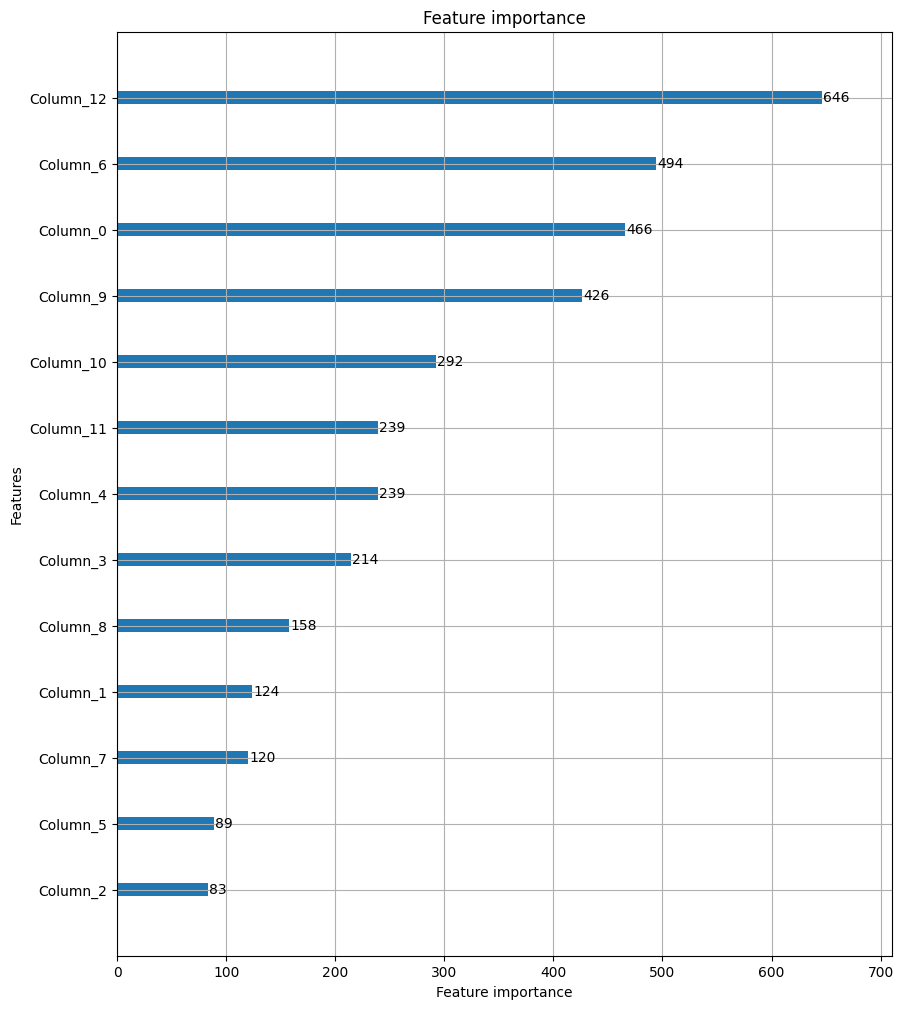

In [36]:
# 빈칸을 채워 시각화 코드를 완성하세요.
fig, ax = plt.subplots(figsize=(10, 12))

# 모델 내장 시각화 함수 호출
plot_importance(lgbm_wrapper, ax=ax)

plt.show()

# 4. 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

문제를 풀기 전, 아래 코드를 실행하여 데이터셋을 준비하세요.

In [37]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

# 와인 데이터셋 로드
wine = load_wine()
X_features = wine.data
y_label = wine.target

# 학습/테스트 데이터 분리 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)


## 문제1. HyperOpt 검색 공간(Search Space) 설정

HyperOpt를 사용하여 하이퍼 파라미터의 검색 범위를 지정하려고 합니다. 다음 조건에 맞게 빈칸을 채우세요.

• max_depth: 3에서 15까지 1 간격으로 탐색

• learning_rate: 0.01에서 0.3 사이에서 균등분포로 탐색

• colsample_bytree: 0.6에서 1.0 사이에서 균등분포로 탐색

In [38]:
from hyperopt import hp
# 빈칸을 채워 검색 공간을 설정하세요.
wine_search_space = {
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
}

##2. 목적 함수(Objective Function) 정의

fmin() 함수가 참조할 목적 함수를 정의해야 합니다.

cross_val_score를 이용해 3-폴드 교차 검증 정확도를 계산하고, 이를 최적화(최소화)할 수 있는 형태로 반환하도록 빈칸을 채우세요.

In [39]:
from sklearn.model_selection import cross_val_score

def objective_func(search_space):
    xgb_clf = XGBClassifier(
        n_estimators=100,
        max_depth=int(search_space['max_depth']),
        learning_rate=search_space['learning_rate'],
        colsample_bytree=search_space['colsample_bytree'],
        eval_metric='mlogloss' # 다중 분류이므로 mlogloss 사용
    )

    # 3-폴드 교차 검증 수행
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # HyperOpt는 'loss' 값을 최소화하는 방향으로 작동합니다.
    # 정확도는 높을수록 좋으므로, ( -1 * np.mean(accuracy) )를 곱하여 반환해야 합니다.
    return {'loss': -1 * np.mean(accuracy), 'status': STATUS_OK}

##문제 3.  fmin을 이용한 최적화 수행

정의한 검색 공간과 목적 함수를 바탕으로 실제 최적화를 수행하는 코드입니다.

베이지안 최적화 알고리즘으로 tpe.suggest를 사용하고, 총 30회 반복하도록 빈칸을 채우세요.

In [40]:
from hyperopt import Trials, fmin, tpe, STATUS_OK # Added missing imports
import numpy as np # Added for np.random.default_rng

# 실행 이력을 저장할 Trials 객체 생성
trial_val = Trials()

# 최적 하이퍼 파라미터 도출
best_params = fmin(
    fn=objective_func,
    space=wine_search_space,
    algo=tpe.suggest, # 최적화 알고리즘 지정
    max_evals=30, # 반복 횟수 지정
    trials=trial_val,
    rstate=np.random.default_rng(seed=42)
)

print('Best Hyperparameters:', best_params)

100%|██████████| 30/30 [00:07<00:00,  3.89trial/s, best loss: -0.978871158392435]
Best Hyperparameters: {'colsample_bytree': np.float64(0.7149425279412935), 'learning_rate': np.float64(0.03802694724633265), 'max_depth': np.float64(9.0)}


## 문제 4. 최적 파라미터 적용 및 조기 중단(Early Stopping)

최적화된 파라미터 best_params를 사용하여 최종 모델을 학습시키고자 합니다.

max_depth는 실수형으로 반환되므로 정수형으로 변환해야 하며, 검증 데이터 세트를 사용하여 50회 동안 성능 개선이 없으면 조기 중단하도록 빈칸을 채우세요.

In [41]:
# 최적 파라미터 적용
xgb_final = XGBClassifier(
    n_estimators=500,
    learning_rate=best_params['learning_rate'],
    max_depth=int(best_params['max_depth']),
    colsample_bytree=best_params['colsample_bytree'],
    # 최신 XGBoost는 모델 생성 시점에 early_stopping_rounds를 넣는 것이 표준입니다.
    early_stopping_rounds=50
)

evals = [(X_val, y_val)]

# 모델 학습 (XGBoost는 eval_set만 넣어주면 내부적으로 조기 중단을 수행합니다)
xgb_final.fit(
    X_tr, y_tr,
    eval_set=evals,
    verbose=100 # 100회마다 결과 출력하고 싶다면?
)

final_preds = xgb_final.predict(X_test)
print(f"최종 정확도: {accuracy_score(y_test, final_preds):.4f}")

[0]	validation_0-mlogloss:1.00193
[100]	validation_0-mlogloss:0.21082
[200]	validation_0-mlogloss:0.15789
[300]	validation_0-mlogloss:0.15082
[400]	validation_0-mlogloss:0.14207
[499]	validation_0-mlogloss:0.14169
최종 정확도: 1.0000




---



# 문제 5. 분류 실습 - 뇌졸중 데이터셋

먼저 데이터셋을 다운로드 해주세요.

데이터는 https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset에서 다운로드하시면 됩니다.

캐글에 로그인한 후 해당 웹페이지에서 csv파일 다운로드 후, pc에 저장해주세요.

In [42]:
#실행해주세요.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [44]:
#데이터를 로드해주세요. (구글 코랩이라면 아래 실행해 파일 업로드)
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [45]:
#실행해주세요.

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

## [문제 5-1] 데이터 전처리

bmi 컬럼의 누락된 값(NaN)을 해당 컬럼의 평균값으로 대체하는 판다스 함수를 작성하세요.

(빈칸을 완성하여, 코드를 실행하세요.)

In [48]:
# 2. 전처리
# ID 제거 및 결측치 처리
# bmi 컬럼의 누락된 값(NaN)을 해당 컬럼의 평균값으로 대체하는 판다스 함수를 작성하세요.
# (빈칸을 완성하여, 코드를 실행하세요.)

df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

## [문제 5-2] 범주형 변수 레이블 인코딩

문자열 데이터를 수치형 데이터로 변환하기 위한 사이킷런의 레이블 인코딩 클래스를 호출하세요.

(빈칸을 완성하여, 코드를 실행하세요.)

In [49]:
from sklearn.preprocessing import LabelEncoder
# 범주형 변수 레이블 인코딩
# 문자열 데이터를 수치형 데이터로 변환하기 위한 사이킷런의 레이블 인코딩 클래스를 호출하세요.
cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

## [문제 5-3] 최종 메타 모델 정의

테스트 데이터용 메타 피처를 생성하세요. (평균 활용)

(빈칸을 완성하여, 코드를 실행하세요.)

In [50]:
# 피처와 레이블 분리 & 데이터 분할
# 실행해주세요.

X_data = df.drop('stroke', axis=1)
y_label = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [51]:
# 3. 개별 모델 및 최종 메타 모델 정의
# 실행해주세요.

knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)
lr_final = LogisticRegression(max_iter=1000)

In [52]:
# 3. CV 기반 스태킹 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    kf = KFold(n_splits=n_folds, shuffle=False)
    train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    test_pred = np.zeros((X_test_n.shape[0], n_folds))

    # K-Fold 교차 검증 반복
    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        X_tr = X_train_n.values[train_index]
        y_tr = y_train_n.values[train_index]
        X_te = X_train_n.values[valid_index]

        model.fit(X_tr, y_tr)
        train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1, 1)
        test_pred[:, folder_counter] = model.predict(X_test_n)

    # [문제 3] 테스트 데이터용 메타 피처 생성하세요. (평균 활용)
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)
    return train_fold_pred, test_pred_mean

In [53]:
# 4. 메타 데이터 생성 및 결합
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 5)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 5)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 5)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 5)

## [문제 5-4] 개별 모델의 예측 결과를 하나의 데이터 세트로 결합

실행 후, 물음에 답하세요. (객관식)

In [54]:
# 개별 모델의 예측 결과를 하나의 데이터 세트로 결합
# 실행해주세요.
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)

[문제 4]
스태킹 과정에서 Stack_final_X_train 데이터 세트의 컬럼(Column) 개수는 몇 개인가?

① 1개  ② 4개  ③ 11개  ④ 데이터 폴드(Fold) 개수와 동일

정답: ② 4개

## [문제 5-5] 최종 메타 모델 학습

최종 정확도를 출력하세요.

(빈칸을 완성하여, 코드를 실행하세요.)

In [55]:
# 5. 최종 메타 모델 학습
lr_final.fit(Stack_final_X_train, y_train)
stack_final_pred = lr_final.predict(Stack_final_X_test)
print('최종 정확도:', accuracy_score(y_test, stack_final_pred))

최종 정확도: 0.9471624266144814
